In [2]:
parPercents=[83.8202, 84.1504, 84.4806, 84.8108, 85.1410, 85.4712, 85.8014, 86.1316, 86.4816, 86.7920, 87.1222, 87.4524, 87.7826, 88.1128, 88.4430]
superfluousPercents=list(range(2, 31, 2))
egPercents=[100-par for par in parPercents]
egPercents

[16.1798,
 15.849599999999995,
 15.519400000000005,
 15.1892,
 14.858999999999995,
 14.528800000000004,
 14.198599999999999,
 13.868399999999994,
 13.5184,
 13.207999999999998,
 12.877799999999993,
 12.547600000000003,
 12.217399999999998,
 11.887200000000007,
 11.557000000000002]

In [3]:
(5.5/807.51)/((5.5/807.51)+(31)/914)

0.16723325929205807

In [4]:
nonsuperfluousPar=[par-sup for par, sup in zip(parPercents, superfluousPercents)]
nonsuperfluousEGPer=[egPer/(egPer+nonSupPar) for egPer, nonSupPar in zip(egPercents, nonsuperfluousPar)]

In [5]:
nonsuperfluousEGPer

[0.1651,
 0.16509999999999994,
 0.16510000000000005,
 0.1651,
 0.16509999999999994,
 0.16510000000000005,
 0.1651,
 0.16509999999999994,
 0.16485853658536584,
 0.16509999999999997,
 0.1650999999999999,
 0.16510000000000002,
 0.16509999999999997,
 0.1651000000000001,
 0.16510000000000002]

(15, 15)

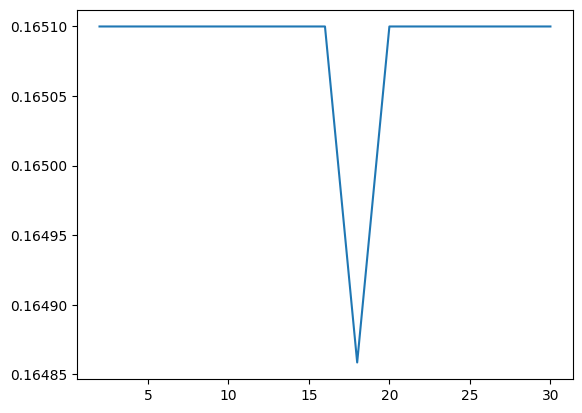

In [6]:
import matplotlib.pyplot as plt
plt.plot(superfluousPercents, nonsuperfluousEGPer)
len(superfluousPercents), len(nonsuperfluousEGPer)

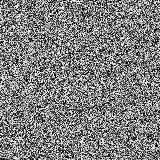

In [7]:
absorptionRate=.1651
import random
import torch
import torchvision as tv
from collections import deque

grid=torch.rand((160, 160))

tensorToImageTransform=tv.transforms.ToPILImage()

def corePhase(grid, prob=0.05):
    return (grid>prob).float()

tensorToImageTransform(grid)

def generateSample(grid, coreProb, growthProb, superfluousPar):
    rows, cols = 160, 160
    totVol=rows*cols
    egVol=0
    bfs=deque()
    for row in range(rows):
        for col in range(cols):
            if random.random()<coreProb:
                grid[row][col]=0
                egVol+=1
                bfs.append([row, col])

    iters=0
    dirs = [[0,1],[0,-1],[1,1],[1,-1],[1,0],[-1,1],[-1,-1],[-1,0]]

    while (totVol-egVol)/totVol>superfluousPar:
        [currX, currY]=bfs.popleft()
        adjWhite=False
        for dir in dirs:
            nx, ny=currX+dir[0], currY+dir[1]
            if nx<0 or nx>=rows or ny<0 or ny>=cols:
                continue
            if random.random()<growthProb and grid[nx][ny]==1:
                egVol+=1
                bfs.append([nx, ny])
                grid[nx][ny]=0
            if grid[nx][ny]==1:
                adjWhite=True
        if adjWhite:
            bfs.append([currX, currY])
    
    return grid

def generateSample2(grid, coreProb, growthProb, superfluousPar):
    rows, cols = 160, 160
    totVol=rows*cols
    egVol=0
    bfs=deque()
    for row in range(rows):
        for col in range(cols):
            if random.random()<coreProb:
                grid[row][col]=0
                egVol+=1
                bfs.append([row, col])

    iters=0
    dirs = [[0,1],[0,-1],[1,1],[1,-1],[1,0],[-1,1],[-1,-1],[-1,0]]

    while (totVol-egVol)/totVol>superfluousPar:
        sz=len(bfs)
        for i in range(sz):
            [currX, currY]=bfs.popleft()
            adjWhite=False
            for dir in dirs:
                nx, ny=currX+dir[0], currY+dir[1]
                if nx<0 or nx>=rows or ny<0 or ny>=cols:
                    continue
                if grid[nx][ny]!=0 and grid[nx][ny]!=1 and grid[nx][ny]-iters<0:
                    grid[nx][ny]=1
                if grid[nx][ny]==1:
                    grid[nx][ny]=random.random()+iters
                    adjWhite=adjWhite or grid[nx][ny]-iters>=growthProb
                if grid[nx][ny]-iters<growthProb and grid[nx][ny]!=0 and grid[nx][ny]!=1:
                    grid[nx][ny]=0
                    egVol+=1
                    bfs.append([nx, ny])
            if adjWhite:
                bfs.append([currX, currY])
        print(egVol)
        iters+=1
        
    return grid

def generateSample3(rows, cols, coreProb, growthProb, wtPercent):
    growthMaterial=(int)(wtPercent>=4)
    vol=0
    totVol=rows*cols
    pDensity=914
    egDensity=269
    egPerSaturatedEG=0.1651
    nonGrowthEndingVol=(wtPercent/egDensity)/(egPerSaturatedEG*(wtPercent/egDensity+(100-wtPercent)/pDensity)) if wtPercent<4 else 1-(wtPercent/egDensity)/(egPerSaturatedEG*(wtPercent/egDensity+(100-wtPercent)/pDensity))
    grid=[[(int)(not growthMaterial)]*cols for i in range(rows)]
    cores=[]
    for row in range(rows):
        for col in range(cols):
            if random.random()<coreProb:
                grid[row][col]=growthMaterial
                vol+=1
                cores.append([row, col])

    dirs = [[0,1],[0,-1],[1,1],[1,-1],[1,0],[-1,1],[-1,-1],[-1,0]]
    iters=0
    prevVol=0

    print(nonGrowthEndingVol, vol, totVol)
    
    while vol/totVol<nonGrowthEndingVol:
        idx=random.randint(0, len(cores)-1)
        [currX, currY]=cores[idx]
        adjNonGrowth=False
        for dir in dirs:
            nx, ny=currX+dir[0], currY+dir[1]
            if nx<0 or nx>=rows or ny<0 or ny>=cols:
                continue
            if grid[nx][ny]!=growthMaterial and random.random()<growthProb:
                grid[nx][ny]=growthMaterial
                cores.append([nx, ny])
                vol+=1
            if grid[nx][ny]!=growthMaterial:
                adjNonGrowth=True
        if not adjNonGrowth:
            cores[idx], cores[-1]=cores[-1], cores[idx]
            cores.pop()
        iters+=1
        if iters%(10000/growthProb)==0:
            print(iters, vol/totVol, vol, totVol, nonGrowthEndingVol, len(cores))
            if prevVol==vol:
                break
            prevVol=vol
    
    return grid



# grid=generateSample(grid, 0.002, 0.25, 0.2)
display(tensorToImageTransform(grid))

In [8]:
import cProfile
# grid=torch.rand((160, 160))
# grid=[[1]*160 for i in range(160)]
grid=generateSample3(160, 160, (random.random()%0.0005)+0.0005, 0.05, random.random()*5)

0.6461393901711343 27 25600


16542


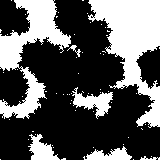

In [9]:
grid_tensor=torch.tensor(grid, dtype=torch.float32)
print(len(torch.nonzero(grid_tensor==0)))
display(tensorToImageTransform(grid_tensor))

In [14]:
#eg true density
egDensity=268.934
parDensity=914
egPerSaturatedEG=0.1651

totVol=160*160
saturatedEgVol=len(torch.nonzero(grid_tensor==0))
superfluousParVol=totVol-saturatedEgVol
parVol=superfluousParVol+(1-egPerSaturatedEG)*saturatedEgVol
egVol=egPerSaturatedEG*saturatedEgVol
egWeight=egVol*egDensity
parWeight=parVol*parDensity
egWeight/(egWeight+parWeight)

0.014395646217211245

In [15]:
saturatedEgDensity=807.51
egDensities=[(saturatedEgDensity-(1-egPerSaturatedEG)*parDensity)/egPerSaturatedEG]
egDensities

[268.99697153240436]

In [12]:
import numpy as np

def lbm_np(grid):
    # setting constants, temperature field, and distribution function
    parRelaxTime=0.5368218517
    # parRelaxTime=0.5030136573
    satEGRelaxTime=0.978183
    # satEGRelaxTime=0.7988643694

    tHot=293
    tCold=283
    tInitial=(tHot+tCold)/2

    rows=len(grid)
    cols=len(grid[0])
    if type(grid) is list:
        grid=np.array(grid)
    omega=1/4

    directions=np.array([[1,0],[0,1],[-1,0],[0,-1]])
    T=np.full((rows, cols), tInitial)
    distributionFunction=np.zeros((4, rows, cols))
    
    def applyBoundaryConditions(T, distributionFunction):
        # Apply temperature boundary conditions
        T[:, 0] = tHot  # Left boundary
        T[:, -1] = tCold  # Right boundary
        
        # Set equilibrium distributions for vertical boundaries
        distributionFunction[0, :, 0] = omega * T[:, 0]
        distributionFunction[2, :, -1] = omega * T[:, -1]

        # Redistribute horizontal flux at vertical boundaries
        distributionFunction[1, :, -1] += distributionFunction[1, :, -2] - omega * T[:, -2]
        distributionFunction[3, :, 0] += distributionFunction[3, :, 1] - omega * T[:, 1]
        
        # Handle corners explicitly
        handleCornerOverlap(distributionFunction)

    def handleCornerOverlap(distributionFunction):
        # Top-left corner (0,0)
        avg_flux_tl = (distributionFunction[1, 0, 1] + distributionFunction[3, 1, 0]) / 2
        distributionFunction[1, 0, 0] = avg_flux_tl
        distributionFunction[3, 0, 0] = avg_flux_tl

        # Top-right corner (0, cols-1)
        avg_flux_tr = (distributionFunction[3, 1, -1] + distributionFunction[0, 0, -2]) / 2
        distributionFunction[0, 0, -1] = avg_flux_tr
        distributionFunction[3, 0, -1] = avg_flux_tr

        # Bottom-left corner (rows-1, 0)
        avg_flux_bl = (distributionFunction[1, -1, 1] + distributionFunction[2, -2, 0]) / 2
        distributionFunction[1, -1, 0] = avg_flux_bl
        distributionFunction[2, -1, 0] = avg_flux_bl

        # Bottom-right corner (rows-1, cols-1)
        avg_flux_br = (distributionFunction[2, -2, -1] + distributionFunction[0, -1, -2]) / 2
        distributionFunction[2, -1, -1] = avg_flux_br
        distributionFunction[0, -1, -1] = avg_flux_br

    def equilibriumDistribution(T):
        return T * omega

    def calculateTemperature(distributionFunction):
        return np.sum(distributionFunction, axis=0)

    def collisionStep(distributionFunction, relaxMap):
        T = calculateTemperature(distributionFunction)
        eq = equilibriumDistribution(T)
        for dir in range(4):
            distributionFunction[dir, 1:-1, :] -= (distributionFunction[dir, 1:-1, :] - eq[1:-1, :]) / relaxMap[1:-1, :]
            if dir != 0:
                distributionFunction[dir, -1, :] -= (distributionFunction[dir, -1, :] - T[-1, :] / 3) / relaxMap[-1, :]
            if dir != 2:
                distributionFunction[dir, 0, :] -= (distributionFunction[dir, 0, :] - T[0, :] / 3) / relaxMap[0, :]

    def shift(array, shift_x, shift_y):
        shifted_array = np.copy(array)
        # Shift rows
        if shift_x > 0:
            shifted_array[shift_x:, :] = array[:-shift_x, :]
            shifted_array[:shift_x, :] = 0
        elif shift_x < 0:
            shifted_array[:shift_x, :] = array[-shift_x:, :]
            shifted_array[shift_x:, :] = 0
        # Shift columns
        if shift_y > 0:
            shifted_array[:, shift_y:] = shifted_array[:, :-shift_y]
            shifted_array[:, :shift_y] = tHot / 4
        elif shift_y < 0:
            shifted_array[:, :shift_y] = shifted_array[:, -shift_y:]
            shifted_array[:, shift_y:] = tCold / 4
        return shifted_array

    def streamingStep(distributionFunction):
        for dir, (x, y) in enumerate(directions):
            distributionFunction[dir] = shift(distributionFunction[dir], shift_x=x, shift_y=y)

        # Redistribute for horizontal boundary overlap
        bottomVelo = distributionFunction[0, -1, 1:-1]
        topVelo = distributionFunction[2, 0, 1:-1]
        distributionFunction[:, -1, 1:-1] += bottomVelo / 3
        distributionFunction[:, 0, 1:-1] += topVelo / 3
        distributionFunction[0, -1, 1:-1] = 0
        distributionFunction[2, 0, 1:-1] = 0

    def calculateThermalConductivity(distributionFunction):
        deltaT = tHot - tCold
        qFlux = (np.sum(distributionFunction[1, :, :]) - np.sum(distributionFunction[3, :, :])) * (np.mean(relaxMap) - 0.5) / np.mean(relaxMap)
        return 1000 * qFlux / (deltaT * rows * cols)

    # setting up initial conditions
    numSteps=100000
    tolerance=1e-9
    relaxMap=np.where(grid==1, parRelaxTime, satEGRelaxTime)

    # initialize velocities
    for dir in range(4):
        distributionFunction[dir,:,:]=equilibriumDistribution(T)
    distributionFunction[:,0,:]=T[0,:]/3
    distributionFunction[:,-1,:]=T[-1,:]/3
    distributionFunction[2,0,:]=0
    distributionFunction[0,-1,:]=0
    applyBoundaryConditions(T, distributionFunction)
    
    for step in range(numSteps):
        T_old=T.copy()
        for dir in range(4):
            collisionStep(distributionFunction, relaxMap)
        streamingStep(distributionFunction)
        T=calculateTemperature(distributionFunction)
        applyBoundaryConditions(T, distributionFunction)
        T=calculateTemperature(distributionFunction)
        if step%100==0:
            print('step:', step, 'TC:', calculateThermalConductivity(distributionFunction))
        error=np.sqrt(np.sum(np.square((T-T_old)))/np.sum(np.square(T)))
        if error<tolerance:
            print("CONVERGED ON STEP", step, "WITH ERROR", error)
            break
    plt.imshow(distributionFunction[1,1:-1,1:-1]-distributionFunction[3,1:-1,1:-1], cmap='hot', interpolation='nearest')
    plt.colorbar()
    return T, calculateThermalConductivity(distributionFunction)
tHot=293
tCold=283
grid1=[[1 for c in range(160)] for r in range(160)]
temps, cond=lbm_np(grid1)

step: 0 TC: 0.17585513427718819
step: 100 TC: 5.201969947959901
step: 200 TC: 6.021030088305885
step: 300 TC: 6.3485574111508445
step: 400 TC: 6.520351146933593
step: 500 TC: 6.625366048152502
step: 600 TC: 6.696190536343751
step: 700 TC: 6.747300142447732
step: 800 TC: 6.786026664622748
step: 900 TC: 6.816454959304972
step: 1000 TC: 6.841031561161371
step: 1100 TC: 6.861308106516946
step: 1200 TC: 6.878316281071855
step: 1300 TC: 6.892770291728297
step: 1400 TC: 6.905182260259552
step: 1500 TC: 6.915930917892008
step: 1600 TC: 6.925304019165068
step: 1700 TC: 6.933525377251429
step: 1800 TC: 6.940772602693365


KeyboardInterrupt: 

In [16]:
test1=np.zeros((4,2,4))
test2=np.array([1,2,3,4])
test1[:,0,:]+=test2
test1

array([[[1., 2., 3., 4.],
        [0., 0., 0., 0.]],

       [[1., 2., 3., 4.],
        [0., 0., 0., 0.]],

       [[1., 2., 3., 4.],
        [0., 0., 0., 0.]],

       [[1., 2., 3., 4.],
        [0., 0., 0., 0.]]])

In [17]:
rows, cols=4, 4
T=np.full((rows, cols), (tHot+tCold)/2)
tauMap=np.full((rows, cols), 0.5)
T[:,0]=tHot
T[:,-1]=tCold
omega=1/4
distF=np.zeros((4, rows, cols))
distF[:,:,:]=T[:,:]*omega
distF

array([[[73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75]],

       [[73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75]],

       [[73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75]],

       [[73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75]]])

In [18]:
distF[:,0,1:-1]+=distF[2,0,1:-1]/3
distF[2,0,1:-1]=0
distF[:,-1,1:-1]+=distF[0,-1,1:-1]/3
distF[0,-1,1:-1]=0
distF

array([[[73.25, 96.  , 96.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25,  0.  ,  0.  , 70.75]],

       [[73.25, 96.  , 96.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 96.  , 96.  , 70.75]],

       [[73.25,  0.  ,  0.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 96.  , 96.  , 70.75]],

       [[73.25, 96.  , 96.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 96.  , 96.  , 70.75]]])

In [19]:
for dir in range(4):
    distF[dir,1:-1,:]-=(distF[dir,1:-1,:]-T[1:-1,:]*omega)/tauMap[1:-1,:]
distF

array([[[73.25, 96.  , 96.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25,  0.  ,  0.  , 70.75]],

       [[73.25, 96.  , 96.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 96.  , 96.  , 70.75]],

       [[73.25,  0.  ,  0.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 96.  , 96.  , 70.75]],

       [[73.25, 96.  , 96.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 96.  , 96.  , 70.75]]])

In [20]:
for dir in range(4):
    if dir!=2:
        distF[dir,0,1:-1]-=(distF[dir,0,1:-1]-T[0,1:-1]/3)/tauMap[0,1:-1]
    if dir!=0:
        distF[dir,-1,1:-1]-=(distF[dir,-1,1:-1]-T[-1,1:-1]/3)/tauMap[-1,1:-1]
distF

array([[[73.25, 96.  , 96.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25,  0.  ,  0.  , 70.75]],

       [[73.25, 96.  , 96.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 96.  , 96.  , 70.75]],

       [[73.25,  0.  ,  0.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 96.  , 96.  , 70.75]],

       [[73.25, 96.  , 96.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 96.  , 96.  , 70.75]]])

In [21]:
np.sum(distF, axis=0)

array([[293., 288., 288., 283.],
       [293., 288., 288., 283.],
       [293., 288., 288., 283.],
       [293., 288., 288., 283.]])

In [22]:
def shift(array, shift_x, shift_y):
    shifted_array=np.copy(array)

    # Shift along the x-axis (rows)
    if shift_x>0:
        shifted_array[shift_x:, :]=array[:-shift_x, :]
        shifted_array[:shift_x, :]=0
    elif shift_x<0:
        shifted_array[:shift_x, :]=array[-shift_x:, :]
        shifted_array[shift_x:, :]=0

    # Shift along the y-axis (columns)
    if shift_y>0:
        shifted_array[:, shift_y:]=shifted_array[:, :-shift_y]
        shifted_array[:, :shift_y]=tHot/4
    elif shift_y<0:
        shifted_array[:, :shift_y]=shifted_array[:, -shift_y:]
        shifted_array[:, shift_y:]=tCold/4
    return shifted_array
dirs=[[1,0],[0,1],[-1,0],[0,-1]]
for dir, [x,y] in enumerate(dirs):
    distF[dir]=shift(distF[dir], x, y)
distF

array([[[ 0.  ,  0.  ,  0.  ,  0.  ],
        [73.25, 96.  , 96.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75]],

       [[73.25, 73.25, 96.  , 96.  ],
        [73.25, 73.25, 72.  , 72.  ],
        [73.25, 73.25, 72.  , 72.  ],
        [73.25, 73.25, 96.  , 96.  ]],

       [[73.25, 72.  , 72.  , 70.75],
        [73.25, 72.  , 72.  , 70.75],
        [73.25, 96.  , 96.  , 70.75],
        [ 0.  ,  0.  ,  0.  ,  0.  ]],

       [[96.  , 96.  , 70.75, 70.75],
        [72.  , 72.  , 70.75, 70.75],
        [72.  , 72.  , 70.75, 70.75],
        [96.  , 96.  , 70.75, 70.75]]])

In [23]:
distF[:,:,0]=tHot*omega
distF[:,:,-1]=tCold*omega
T=np.sum(distF, axis=0)
T, np.sum(distF, axis=0)

(array([[293.  , 241.25, 238.75, 283.  ],
        [293.  , 313.25, 310.75, 283.  ],
        [293.  , 313.25, 310.75, 283.  ],
        [293.  , 241.25, 238.75, 283.  ]]),
 array([[293.  , 241.25, 238.75, 283.  ],
        [293.  , 313.25, 310.75, 283.  ],
        [293.  , 313.25, 310.75, 283.  ],
        [293.  , 241.25, 238.75, 283.  ]]))

-2.3424061703636312e-05 8 25600
25592


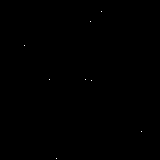

In [183]:
grid=generateSample3(160, 160, (random.random()%0.0005)+0.0005, 0.05, 5.5)#random.random()*5)
grid_tensor=torch.tensor(grid, dtype=torch.float32)
print(len(torch.nonzero(grid_tensor==0)))
display(tensorToImageTransform(grid_tensor))

In [109]:
# grid=[[0 for i in range(160)] for j in range(160)]
if type(grid) is list:
    grid=np.array(grid)
rows, cols=160, 160
tHot=293
tCold=283
parRelaxTime=0.5588
satEGRelaxTime=0.97
T=np.full((rows, cols), (tHot+tCold)/2)
# tauMap=np.full((rows, cols), 0.5588)
tauMap=np.where(grid==1, parRelaxTime, satEGRelaxTime)
vert=np.where(grid==1, 0.157, 0.244375)
# vert=np.where(grid==1, 0.157, 0.24)
horiz=(1-vert)/2
T[:,0]=tHot
T[:,-1]=tCold
omega=1/4
distF=np.zeros((4, rows, cols))
distF[:,:,:]=T[:,:]*omega
tolerance=1e-7
for i in range(1000000):
    T_old=T.copy()

    # redistribute heat on top and bottom boundary
    distF[0,0,1:-1]+=distF[2,0,1:-1]*vert[0,1:-1]
    distF[1,0,1:-1]+=distF[2,0,1:-1]*horiz[0,1:-1]
    distF[3,0,1:-1]+=distF[2,0,1:-1]*horiz[0,1:-1]
    distF[2,0,1:-1]=0
    distF[2,-1,1:-1]+=distF[0,-1,1:-1]*vert[-1,1:-1]
    distF[1,-1,1:-1]+=distF[0,-1,1:-1]*horiz[-1,1:-1]
    distF[3,-1,1:-1]+=distF[0,-1,1:-1]*horiz[-1,1:-1]
    distF[0,-1,1:-1]=0

    # collision on non top/bottom boundary
    for dir in range(4):
        distF[dir,1:-1,:]-=(distF[dir,1:-1,:]-T[1:-1,:]*omega)/tauMap[1:-1,:]

    # collision on top/bottom boundary
    for dir in range(4):
        if dir%2==1:
            distF[dir,0,1:-1]-=(distF[dir,0,1:-1]-T[0,1:-1]*horiz[0,1:-1])/tauMap[0,1:-1]
            distF[dir,-1,1:-1]-=(distF[dir,-1,1:-1]-T[-1,1:-1]*horiz[-1,1:-1])/tauMap[-1,1:-1]
        if dir==0:
            distF[dir,0,1:-1]-=(distF[dir,0,1:-1]-T[0,1:-1]*vert[0,1:-1])/tauMap[0,1:-1]
        if dir==2:
            distF[dir,-1,1:-1]-=(distF[dir,-1,1:-1]-T[-1,1:-1]*vert[-1,1:-1])/tauMap[-1,1:-1]
            
    # streaming step
    for dir, [x,y] in enumerate(dirs):
        distF[dir]=shift(distF[dir], x, y)

    # set temps after streaming
    T=np.sum(distF, axis=0)
    
    # reset left/right boundary conditions
    distF[:,:,0]=tHot*omega
    distF[:,:,-1]=tCold*omega

    # # corner boundary handling
    distF[1,-1,0]+=tHot*omega/2
    distF[3,-1,0]+=tHot*omega/2
    distF[0,-1,0]=0
    distF[1,0,0]+=tHot*omega/2
    distF[3,0,0]+=tHot*omega/2
    distF[2,0,0]=0
    distF[1,-1,-1]+=tCold*omega/2
    distF[3,-1,-1]+=tCold*omega/2
    distF[0,-1,-1]=0
    distF[1,0,-1]+=tCold*omega/2
    distF[3,0,-1]+=tCold*omega/2
    distF[2,0,-1]=0

    # update temp
    T=np.sum(distF, axis=0)

    # verify how much temp changed 
    error=np.sqrt(np.sum(np.square((T-T_old)))/np.sum(np.square(T)))
    if i%10000==0:
        print(i, error)
        # print(distF[1,-1,:]-distF[3,-1,:])
    if error<tolerance:
        print("CONVERGED ON STEP", i, "WITH ERROR", error)
        break
# Calculate thermal conductivity
deltaT=tHot-tCold
qFlux=(np.sum(distF[1,:,:])-np.sum(distF[3,:,:]))*(np.mean(tauMap[:,:])-0.5)/np.mean(tauMap[:,:])
cond=1000*qFlux/(deltaT*rows*cols)
cond

0 0.021205263269236874
10000 5.08962121158521e-07
20000 2.0865084096957612e-07
CONVERGED ON STEP 29053 WITH ERROR 9.999955481074322e-08


0.8054665359138489

In [184]:
# grid=[[1 for i in range(160)] for j in range(160)]
if type(grid) is list:
    grid=np.array(grid)
rows, cols=160, 160
tHot=293
tCold=283
parRelaxTime=0.5588
satEGRelaxTime=0.97
parRelaxTime=0.5975
satEGRelaxTime=1.175
T=np.full((rows, cols), (tHot+tCold)/2)
tauMap=np.where(grid==1, parRelaxTime, satEGRelaxTime)
T[:,0]=tHot
T[:,-1]=tCold
omega=1/4
distF=np.zeros((4, rows, cols))
distF[:,:,:]=T[:,:]*omega
tolerance=1e-7
for i in range(1000000):
    T_old=T.copy()

    # collision
    for dir in range(4):
        distF[dir,:,:]-=(distF[dir,:,:]-T[:,:]*omega)/tauMap[:,:]
            
    # streaming step
    for dir, [x,y] in enumerate(dirs):
        distF[dir]=shift(distF[dir], x, y)

    # top/bottom neumann boundary conditions
    distF[0,0,:]=distF[2,0,:]
    distF[2,-1,:]=distF[0,-1,:]

    # reset left/right boundary conditions
    distF[1,:,0]=tHot-distF[0,:,0]-distF[2,:,0]-distF[3,:,0]
    distF[3,:,-1]=tCold-distF[0,:,-1]-distF[1,:,-1]-distF[2,:,-1]

    # update temp
    T=np.sum(distF, axis=0)

    # verify how much temp changed 
    error=np.sqrt(np.sum(np.square((T-T_old)))/np.sum(np.square(T)))
    if i%10000==0:
        print(i, error)
        # print(distF[1,-1,:]-distF[3,-1,:])
    if error<tolerance:
        print("CONVERGED ON STEP", i, "WITH ERROR", error)
        break
# Calculate thermal conductivity
deltaT=tHot-tCold
qFlux=(np.sum(distF[1,:,:])-np.sum(distF[3,:,:]))*(np.mean(tauMap[:,:])-0.5)/np.mean(tauMap[:,:])
cond=1000*qFlux/(deltaT*rows*cols)
cond

0 0.0004852568363577819
CONVERGED ON STEP 7053 WITH ERROR 9.996950074357507e-08


2.122192164038457

In [185]:
deltaT=tHot-tCold
qFlux=np.sum((distF[1,:,:]-distF[3,:,:])*(tauMap-0.5)/tauMap)
cond=1000*qFlux/(deltaT*rows*cols)
cond

2.1218081898663788

In [186]:
deltaT=tHot-tCold
qFlux=(np.sum(distF[1,:,:])-np.sum(distF[3,:,:]))*(np.mean(tauMap[:,:])-0.5)/np.mean(tauMap[:,:])
cond=1000*qFlux/(deltaT*rows*cols)
cond

2.122192164038457

paraffin temps 287.9913016709015 8
sat eg temps 288.000019525273 25592
paraffin heat diff(left/right) 0.048665207280812695
sat eg heat diff(left/right) 0.03694240424542165
paraffin heat flux(left/right) 11.756537611197798
sat eg heat flux(left/right) 0.02122223222609329
paraffin heat flux all directions 0.007935799840646705
sat eg heat flux all directions 0.021221124997900208
total heat flux all directions 0.02121697333378857
tc all directions 2.121697333378857
tc right/left 2.1218081898663788


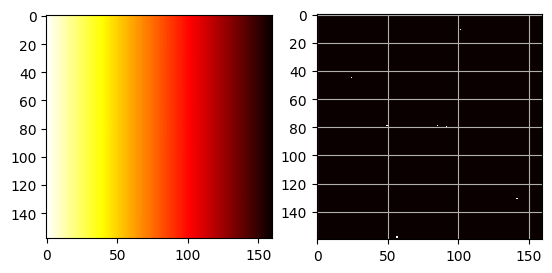

In [187]:
fig, axs=plt.subplots(1,2)
axs[0].imshow(distF[1,1:-1,:], cmap='hot', interpolation='nearest')
axs[1].imshow(grid, cmap='hot', interpolation='nearest')
axs[1].grid()
print('paraffin temps', np.sum(T*grid)/np.sum(grid), np.sum(grid))
print('sat eg temps', np.sum(T*(1-grid))/np.sum(1-grid), np.sum(1-grid))
print('paraffin heat diff(left/right)', (np.sum((distF[1,:,:]-distF[3,:,:])*grid))/np.sum(grid))
print('sat eg heat diff(left/right)', np.sum((distF[1,:,:]-distF[3,:,:])*(1-grid))/np.sum(1-grid))
print('paraffin heat flux(left/right)', np.sum((distF[1,:,:]-distF[3,:,:]+distF[0,:,:])*(tauMap-0.5)/tauMap*(grid))/(np.sum(grid)))
print('sat eg heat flux(left/right)', np.sum((distF[1,:,:]-distF[3,:,:])*(tauMap-0.5)/tauMap*(1-grid))/(np.sum(1-grid)))
print('paraffin heat flux all directions', np.sum((distF[1,:,:]-distF[3,:,:]+distF[0,:,:]-distF[2,:,:])*(tauMap-0.5)/tauMap*(grid))/(np.sum(grid)))
print('sat eg heat flux all directions', np.sum((distF[1,:,:]-distF[3,:,:]+distF[0,:,:]-distF[2,:,:])*(tauMap-0.5)/tauMap*(1-grid))/(np.sum(1-grid)))
print('total heat flux all directions', np.sum((distF[1,:,:]-distF[3,:,:]+distF[0,:,:]-distF[2,:,:])*(tauMap-0.5)/tauMap)/160**2)
print('tc all directions', np.sum((distF[1,:,:]-distF[3,:,:]+distF[0,:,:]-distF[2,:,:])*(tauMap-0.5)/tauMap)/160**2*1000/(tHot-tCold))
print('tc right/left', np.sum((distF[1,:,:]-distF[3,:,:])*(tauMap-0.5)/tauMap)/(160**2*(tHot-tCold))*1000)

[[293.         292.93504176 292.87008674 292.80513817 292.74019925]
 [293.         292.93504176 292.87008674 292.80513817 292.74019925]
 [293.         292.93504176 292.87008674 292.80513817 292.74019925]
 [293.         292.93504176 292.87008674 292.80513817 292.74019925]
 [293.         292.93504176 292.87008674 292.80513817 292.74019925]]
[73.25       73.27435964 73.25       73.22564036]


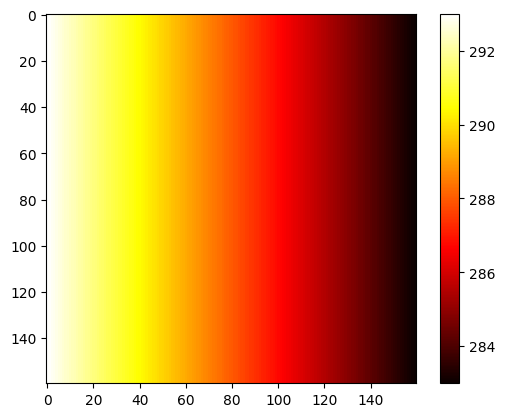

In [141]:
plt.imshow(T[:,:], cmap='hot', interpolation='nearest')
plt.colorbar()
print(T[:5,:5])
print(distF[:,0,0])

[[293.         292.96721364 292.9344416  292.90169778 292.86899606]
 [293.         292.96720695 292.93442822 292.90167812 292.86897015]
 [293.         292.96718668 292.93438808 292.90161855 292.86889238]
 [293.         292.96715261 292.93432036 292.9015184  292.86876109]
 [293.         292.96710413 292.93422422 292.90137584 292.86857456]]
[73.25       73.25795083 73.25       73.24204917]


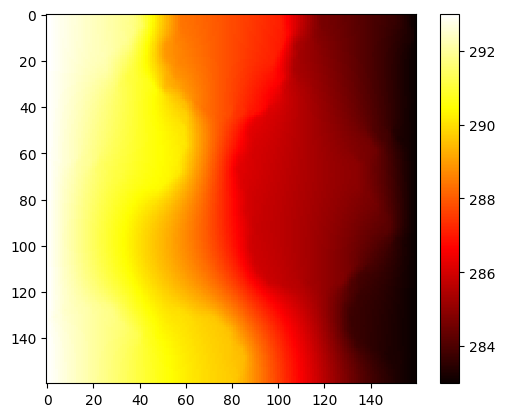

In [115]:
plt.imshow(T[:,:], cmap='hot', interpolation='nearest')
plt.colorbar()
print(T[:5,:5])
print(distF[:,0,0])

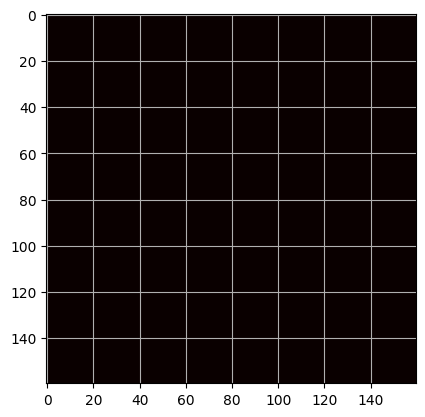

In [138]:
plt.imshow(grid, cmap='hot', interpolation='nearest')
plt.grid()

In [290]:
test1=np.array([1,2,3,4], dtype=np.float32)
test2=np.array([1,2,3,4], dtype=np.float32)
tau1=0.5588
tau2=0.97
for i in range(100):
    equil=np.sum(test1)/4
    for dir in range(4):
        test1-=(test1-equil)/tau1
        test2-=(test2-equil)/tau2
    print('par', test1, np.sum(test1))
    print('eg', test2, np.sum(test2))
    print('par', np.sum(np.abs(test1-equil)), 'eg', np.sum(np.abs(test2-equil)))

par [1.9170817 2.3056939 2.6943061 3.0829182] 10.0
eg [2.4999986 2.4999995 2.5000005 2.5000014] 10.0
par 1.5544487 eg 3.8146973e-06
par [2.2734709 2.4244902 2.5755098 2.7265291] 10.0
eg [2.5 2.5 2.5 2.5] 10.0
par 0.6040778 eg 0.0
par [2.411968 2.470656 2.529344 2.588032] 10.0
eg [2.5 2.5 2.5 2.5] 10.0
par 0.23475218 eg 0.0
par [2.4657896 2.4885967 2.5114033 2.5342104] 10.0
eg [2.5 2.5 2.5 2.5] 10.0
par 0.09122753 eg 0.0
par [2.4867053 2.4955685 2.5044315 2.5132947] 10.0
eg [2.5 2.5 2.5 2.5] 10.0
par 0.035452366 eg 0.0
par [2.4948335 2.4982777 2.5017223 2.5051665] 10.0
eg [2.5 2.5 2.5 2.5] 10.0
par 0.013777733 eg 0.0
par [2.4979923 2.4993305 2.5006695 2.5020077] 10.0
eg [2.5 2.5 2.5 2.5] 10.0
par 0.0053544044 eg 0.0
par [2.4992197 2.49974   2.50026   2.5007803] 10.0
eg [2.5 2.5 2.5 2.5] 10.0
par 0.0020809174 eg 0.0
par [2.4996967 2.499899  2.500101  2.5003033] 10.0
eg [2.5 2.5 2.5 2.5] 10.0
par 0.0008087158 eg 0.0
par [2.4998822 2.499961  2.500039  2.5001178] 10.0
eg [2.5 2.5 2.5 2.5] 1

1.5228620324651698

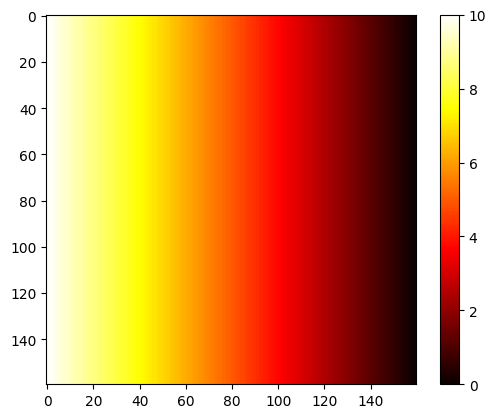

In [78]:
plt.imshow(temps, cmap='hot', interpolation='nearest')
plt.colorbar()
cond

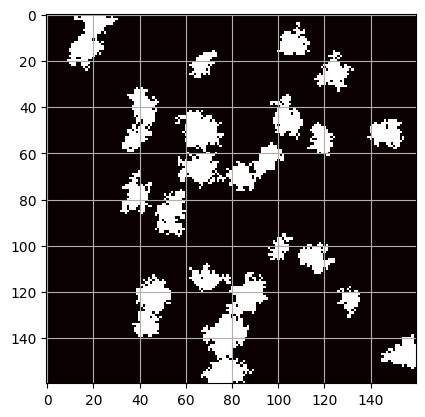

In [69]:
plt.imshow(grid, cmap='hot', interpolation='nearest')
plt.grid()

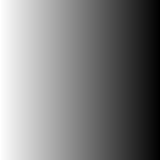

In [ ]:
display(tensorToImageTransform((temps-np.min(temps))/(np.max(temps)-np.min(temps))))

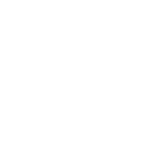

In [ ]:
tensorToImageTransform(torch.tensor(grid1, dtype=torch.float32))

In [ ]:
npGrid=np.array(grid)
np.sum(npGrid==1)/(160*160)

0.0812109375

In [ ]:
test=np.array([[0,1,0,1,0,1],[2,0,2,0,2,0]])
np.roll(test, 1, axis=1)

array([[1, 0, 1, 0, 1, 0],
       [0, 2, 0, 2, 0, 2]])

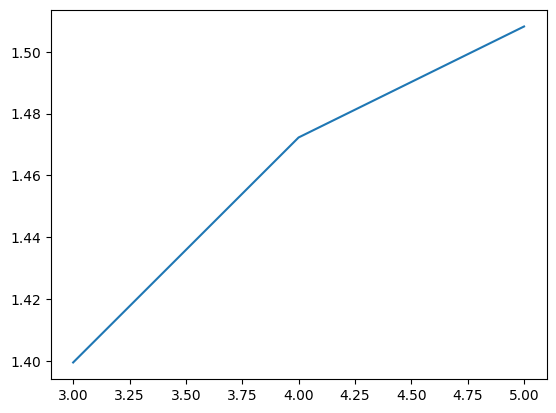

In [ ]:
plt.plot([3,4,5],[1.3995, 1.47226, 1.50815])

In [ ]:
data=[]
for i in range(10000):
    wt=random.random()*5
    core_prob=(random.random()%0.002)+0.0005
    sample=generateSample3(160, 160, core_prob, 0.05, wt)
    temps, cond=lbm_np(sample)
    data.append([sample, temps, cond, wt])
    print('wt:', wt, 'cond:', cond)

0.30453004986295046 31 25600
CONVERGED ON STEP 21439 WITH ERROR 9.999973788212242e-10
wt: 1.534165937744576 cond: 1.1667223527190895
0.4212482970275095 74 25600
CONVERGED ON STEP 26272 WITH ERROR 9.998433653244448e-10
wt: 2.1525192025221247 cond: 1.2864050380704333
0.09962164529622146 35 25600
CONVERGED ON STEP 11363 WITH ERROR 9.997655101987639e-10
wt: 0.48975303934144676 cond: 0.797598933274055
0.4300726984489468 42 25600
CONVERGED ON STEP 25632 WITH ERROR 9.999812876200753e-10
wt: 2.1999892492637607 cond: 1.295871069973577
0.1507327646010039 28 25600
CONVERGED ON STEP 17776 WITH ERROR 9.999947761170982e-10
wt: 0.7455135952278069 cond: 0.9100650386674403
0.17056398137785242 15 25600
CONVERGED ON STEP 21235 WITH ERROR 9.999859888609925e-10
wt: 0.8455860601658294 cond: 0.9468269199342281
0.035144888395691035 62 25600
CONVERGED ON STEP 10802 WITH ERROR 9.996185756176635e-10
wt: 0.1714736076940876 cond: 0.6329054748956956
0.23140618398165802 19 25600
CONVERGED ON STEP 15257 WITH ERROR 9.

KeyboardInterrupt: 

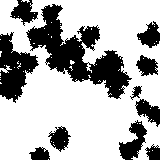

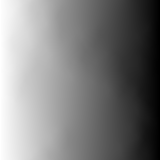

1.1667223527190895


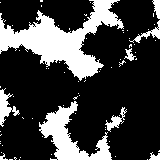

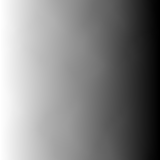

1.476287155674465


(array([187., 160., 191., 182., 168., 182., 199., 175., 166., 205.]),
 array([2.11933672e-03, 5.01904136e-01, 1.00168894e+00, 1.50147373e+00,
        2.00125853e+00, 2.50104333e+00, 3.00082813e+00, 3.50061293e+00,
        4.00039773e+00, 4.50018253e+00, 4.99996733e+00]),
 <BarContainer object of 10 artists>)

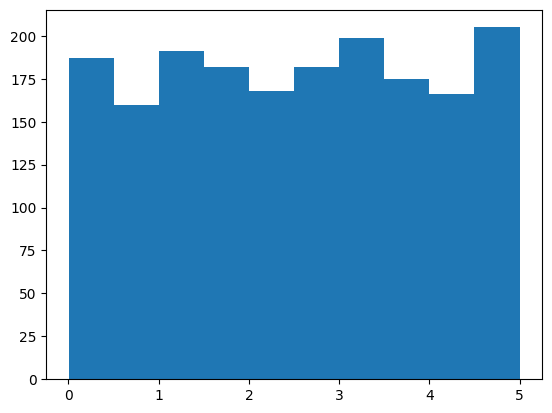

In [ ]:
for i, [sample, temps, cond, wt] in enumerate(data):
    if i%1000==0:
        display(tensorToImageTransform(torch.tensor(sample, dtype=torch.float32)))
        display(tensorToImageTransform((temps-np.min(temps))/(np.max(temps)-np.min(temps))))
        print(cond)
plt.hist([x[-1] for x in data])

Text(0, 0.5, 'Thermal Conductivity(W/mK)')

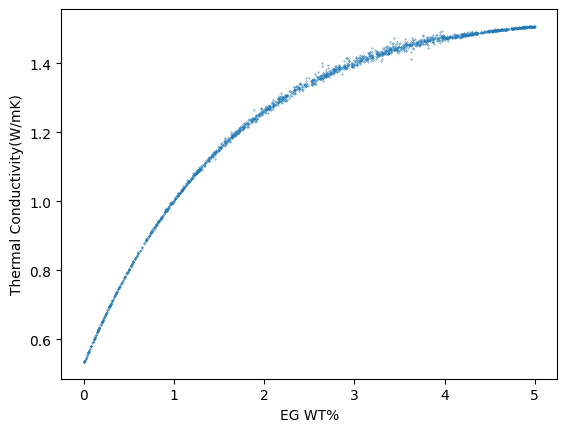

In [ ]:
wts=[data[i][-1] for i in range(len(data))]
conds=[data[i][-2] for i in range(len(data))]
plt.scatter(wts, conds, s=0.1)
plt.xlabel('EG WT%')
plt.ylabel('Thermal Conductivity(W/mK)')

In [ ]:
sfVolPts=[np.array(data[i][0]).sum()/(160*160) for i in range(len(data))]

Text(0, 0.5, 'Thermal Conductivity(W/mK)')

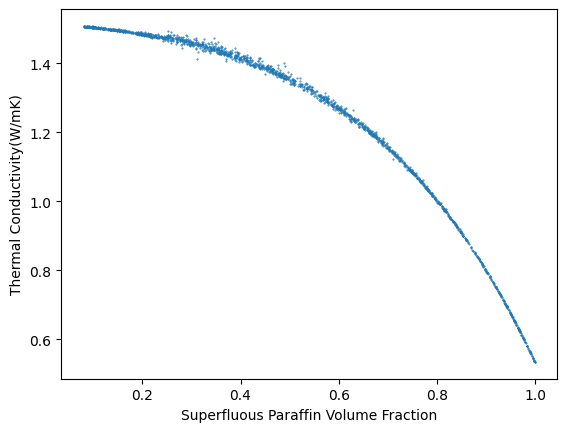

In [ ]:
plt.scatter(sfVolPts, conds, s=0.2)
plt.xlabel('Superfluous Paraffin Volume Fraction')
plt.ylabel('Thermal Conductivity(W/mK)')

In [ ]:
np.savetxt('data1.csv', np.array([[wts[i], sfVolPts[i], conds[i]] for i in range(len(data))]), delimiter=',')

In [ ]:
from PIL import Image
for i, datapoint in enumerate(data):
    sample=Image.fromarray(np.array(datapoint[0])*255).convert('RGB')
    sample.save('./data/samples/'+str(i+1024)+'.jpeg')
    temp=Image.fromarray(255*(datapoint[1]-np.min(datapoint[1]))/(np.max(datapoint[1])-np.min(datapoint[1]))).convert('RGB')
    temp.save('./data/temperatures/'+str(i+1024)+'.jpeg')

+----------------------+
| Geometry information |
+----------------------+
    - spatial dimension: 2
    - bounds of the box: [0. 1.] x [0. 1.]
    - labels: [0, 0, 0, 0]


c:\Users\User\Desktop\Paraffin-EG-Model\venv\Lib\site-packages\pylbm\viewer\matplotlib_viewer.py:516: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  self.ax.grid(visible, which=which, alpha=alpha)


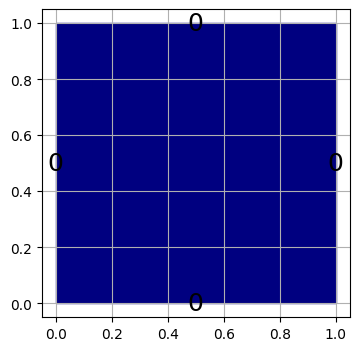

In [ ]:
import numpy as np
import pylbm

xmin, xmax, ymin, ymax = 0., 1., 0., 1.
dico_geom = {
    'box': {'x': [xmin, xmax],
            'y': [ymin, ymax],
            'label': 0
           },
}
geom = pylbm.Geometry(dico_geom)
print(geom)
geom.visualize(viewlabel=True)


+---------------------+
| Stencil information |
+---------------------+
    - spatial dimension: 2
    - minimal velocity in each direction: [-1 -1]
    - maximal velocity in each direction: [1 1]
    - information for each elementary stencil:
        stencil 0
            - number of velocities: 5
            - velocities
                (0: 0, 0)
                (1: 1, 0)
                (2: 0, 1)
                (3: -1, 0)
                (4: 0, -1)


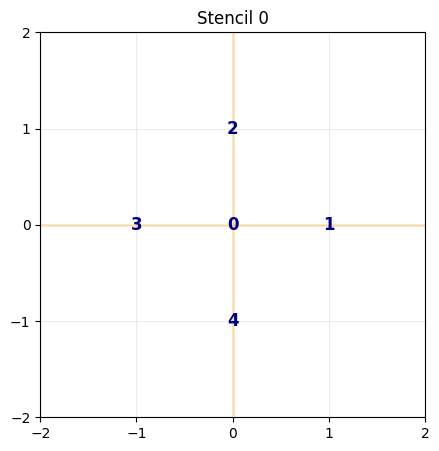

In [ ]:
dico_sten = {
    'dim':2,
    'schemes': [
        {'velocities': list(range(5))}
    ],
}
sten = pylbm.Stencil(dico_sten)
print(sten)
sten.visualize()

+--------------------+
| Domain information |
+--------------------+
    - spatial dimension: 2
    - space step: 0.00625
    - with halo:
        bounds of the box: [-0.003125 -0.003125] x [1.003125 1.003125]
        number of points: [162, 162]
    - without halo:
        bounds of the box: [0.003125 0.003125] x [0.996875 0.996875]
        number of points: [160, 160]
        
    +----------------------+
    | Geometry information |
    +----------------------+
        - spatial dimension: 2
        - bounds of the box: [0. 1.] x [0. 1.]
        - labels: [0, 0, 0, 0]


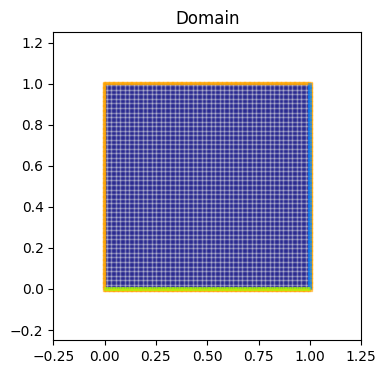

In [ ]:
N = 160
dx = (xmax-xmin)/N
dico_dom = {
    'box': {'x': [xmin, xmax],
            'y': [ymin, ymax],
            'label': 0
           },
    'space_step': dx,
    'schemes': [
        {'velocities': list(range(5)),}
    ],
}
dom = pylbm.Domain(dico_dom)
print(dom)
dom.visualize(view_distance=True);

In [ ]:
import sympy as sp

def solution(x, y, t):
    return np.sin(np.pi*x)*np.sin(np.pi*y)*np.exp(-2*np.pi**2*mu*t)

# parameters
mu = 1.
la = 1.
s1 = 0.588
s2 = 0.588
u, X, Y, LA = sp.symbols('u, X, Y, LA')

dico_sch = {
    'dim': 2,
    'scheme_velocity': la,
    'schemes': [
        {
            'velocities': list(range(5)),
            'conserved_moments': u,
            'polynomials': [1, X/LA, Y/LA, (X**2+Y**2)/(2*LA**2), (X**2-Y**2)/(2*LA**2)],
            'equilibrium': [u, 0., 0., .5*u, 0.],
            'relaxation_parameters': [0., s1, s1, s2, s2],
        }
    ],
    'parameters': {LA: la},
}

sch = pylbm.Scheme(dico_sch)
print(sch)

+--------------------+
| Scheme information |
+--------------------+
    - spatial dimension: 2
    - number of schemes: 1
    - number of velocities: 5
    - conserved moments: [u]
        
    +----------+
    | Scheme 0 |
    +----------+
        - velocities
            (0: 0, 0)
            (1: 1, 0)
            (2: 0, 1)
            (3: -1, 0)
            (4: 0, -1)

        - polynomials
                    
            ⎡   1   ⎤
            ⎢       ⎥
            ⎢  X    ⎥
            ⎢  ──   ⎥
            ⎢  LA   ⎥
            ⎢       ⎥
            ⎢  Y    ⎥
            ⎢  ──   ⎥
            ⎢  LA   ⎥
            ⎢       ⎥
            ⎢ 2    2⎥
            ⎢X  + Y ⎥
            ⎢───────⎥
            ⎢     2 ⎥
            ⎢ 2⋅LA  ⎥
            ⎢       ⎥
            ⎢ 2    2⎥
            ⎢X  - Y ⎥
            ⎢───────⎥
            ⎢     2 ⎥
            ⎣ 2⋅LA  ⎦

        - equilibria
                    
            ⎡  u  ⎤
            ⎢     ⎥
            ⎢ 0.0 ⎥
            ⎢   

c:\Users\User\Desktop\Paraffin-EG-Model\venv\Lib\site-packages\pylbm\viewer\matplotlib_viewer.py:516: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  self.ax.grid(visible, which=which, alpha=alpha)


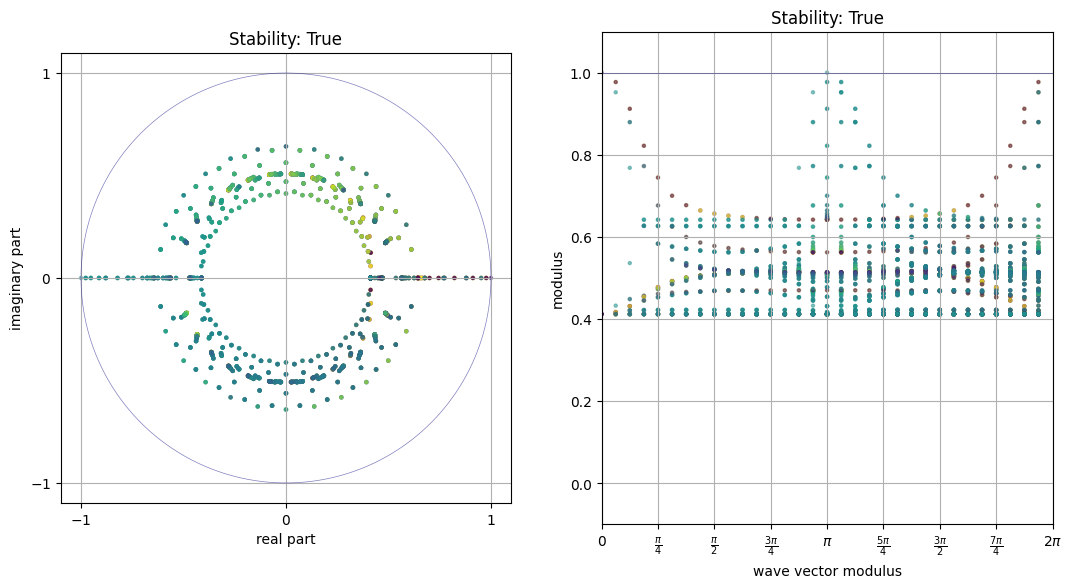

<Figure size 600x200 with 0 Axes>

In [ ]:
pylbm.Stability(sch).visualize()

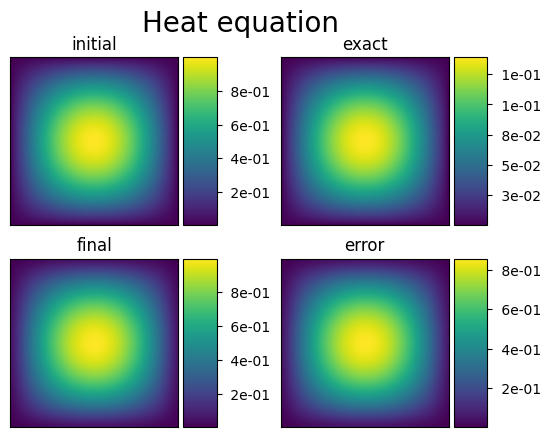

In [ ]:
import numpy as np
import sympy as sp
import pylab as plt
%matplotlib inline
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pylbm

u, X, Y = sp.symbols('u, X, Y')

def solution(x, y, t, k, l):
    return np.sin(k*np.pi*x)*np.sin(l*np.pi*y)*np.exp(-(k**2+l**2)*np.pi**2*mu*t)

def plot(i, j, z, title):
    im = axarr[i,j].imshow(z)
    divider = make_axes_locatable(axarr[i, j])
    cax = divider.append_axes("right", size="20%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax, format='%6.0e')
    axarr[i, j].xaxis.set_visible(False)
    axarr[i, j].yaxis.set_visible(False)
    axarr[i, j].set_title(title)

# parameters
xmin, xmax, ymin, ymax = 0., 1., 0., 1.
N = 160
mu = 1.
Tf = .1
dx = (xmax-xmin)/N # spatial step
la = 1.
s1 = 0.588
s2 = 0.588
k, l = 1, 1 # number of the wave

dico = {
    'box': {'x':[xmin, xmax],
            'y':[ymin, ymax],
            'label': 0},
    'space_step': dx,
    'scheme_velocity': la,
    'schemes':[
        {
            'velocities': list(range(5)),
            'conserved_moments': u,
            'polynomials': [1, X/LA, Y/LA, (X**2+Y**2)/(2*LA**2), (X**2-Y**2)/(2*LA**2)],
            'equilibrium': [u, 0., 0., .5*u, 0.],
            'relaxation_parameters': [0., s1, s1, s2, s2],
        }
    ],
    'init': {u: (solution, (0., k, l))},
    'boundary_conditions': {
        0: {'method': {0: pylbm.bc.Neumann,}},
    },
    'generator': 'cython',
    'parameters': {LA: la},
}
sol = pylbm.Simulation(dico)
x = sol.domain.x
y = sol.domain.y

f, axarr = plt.subplots(2, 2)
f.suptitle('Heat equation', fontsize=20)

plot(0, 0, sol.m[u].copy(), 'initial')

while sol.t < Tf:
    sol.one_time_step()

sol.f2m()
z = sol.m[u]
ze = solution(x[:, np.newaxis], y[np.newaxis, :], sol.t, k, l)
plot(1, 0, z, 'final')
plot(0, 1, ze, 'exact')
plot(1, 1, z-ze, 'error')

plt.show()